<a href="https://colab.research.google.com/github/Steph-business/Tech_Talent_Accelerator/blob/main/Week7_Day1_dalychallenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

```markdown
# Défi quotidien : Analyse textuelle de livres à l'aide d'un nuage de mots

Ce notebook contient les étapes de prétraitement NLP et d'analyse de texte pour les œuvres de Lewis Carroll.
```

In [12]:
import requests
import re
import nltk
import spacy
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('maxent_ne_chunker')
nltk.download('maxent_ne_chunker_tab')
nltk.download('words')

urls = [
    'https://www.gutenberg.org/files/11/11-0.txt',
    'https://www.gutenberg.org/files/12/12-0.txt',
    'https://www.gutenberg.org/cache/epub/29691/pg29691.txt'
]

def load_texts(url_list):
    corpus = []
    for url in url_list:
        response = requests.get(url)
        text = response.text
        cleaned_text = re.sub(r'[^a-zA-Z\s]', '', text)
        corpus.append(cleaned_text)
    return corpus

raw_corpus = load_texts(urls)
print(f"Chargement terminé : {len(raw_corpus)} livres récupérés.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker.zip.
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker_tab.zip.
[nltk_data] Downloading package words to /r

Chargement terminé : 3 livres récupérés.


In [13]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

def trim_text(text):
    """Nettoyage utilisant les balises suggérées."""
    start_marker = " START"
    end_marker = " END"
    start_idx = text.find(start_marker)
    end_idx = text.rfind(end_marker)
    return text[start_idx:end_idx] if (start_idx != -1 and end_idx != -1) else text

trimmed_corpus = [trim_text(t) for t in raw_corpus]
tokenized_corpus = [word_tokenize(t.lower()) for t in trimmed_corpus]
stop_words = set(stopwords.words('english'))
filtered_corpus = [[word for word in book if word.isalpha() and word not in stop_words] for book in tokenized_corpus]

print(f"Prétraitement réussi. Mots dans le livre 1 : {len(filtered_corpus[0])}")

Prétraitement réussi. Mots dans le livre 1 : 12684


In [18]:
# 4. V&#233;rification de la suppression des mots vides (Stopwords)
test_words = ['i', 'me', 'my', 'we', 'our', 'ours', 'ourselves']
for book_idx, book in enumerate(filtered_corpus):
    print(f"--- V&#233;rification Livre {book_idx + 1} ---")
    for sw in test_words:
        print(f"Occurrence de '{sw}': {book.count(sw)}")

--- V&#233;rification Livre 1 ---
Occurrence de 'i': 0
Occurrence de 'me': 0
Occurrence de 'my': 0
Occurrence de 'we': 0
Occurrence de 'our': 0
Occurrence de 'ours': 0
Occurrence de 'ourselves': 0
--- V&#233;rification Livre 2 ---
Occurrence de 'i': 0
Occurrence de 'me': 0
Occurrence de 'my': 0
Occurrence de 'we': 0
Occurrence de 'our': 0
Occurrence de 'ours': 0
Occurrence de 'ourselves': 0
--- V&#233;rification Livre 3 ---
Occurrence de 'i': 0
Occurrence de 'me': 0
Occurrence de 'my': 0
Occurrence de 'we': 0
Occurrence de 'our': 0
Occurrence de 'ours': 0
Occurrence de 'ourselves': 0


In [19]:
from nltk.stem import PorterStemmer
# 5. Stemming (Racinisation)
stemmer = PorterStemmer()
stemmed_tokens = [[stemmer.stem(word) for word in book] for book in filtered_corpus]
print("50 premiers tokens racinis&#233;s (Livre 1) :", stemmed_tokens[0][:50])

50 premiers tokens racinis&#233;s (Livre 1) : ['start', 'project', 'gutenberg', 'ebook', 'illustr', 'alic', 'adventur', 'wonderland', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', 'content', 'chapter', 'rabbithol', 'chapter', 'ii', 'pool', 'tear', 'chapter', 'iii', 'caucusrac', 'long', 'tale', 'chapter', 'iv', 'rabbit', 'send', 'littl', 'bill', 'chapter', 'v', 'advic', 'caterpillar', 'chapter', 'vi', 'pig', 'pepper', 'chapter', 'vii', 'mad', 'teaparti', 'chapter', 'viii', 'queen', 'croquetground', 'chapter', 'ix', 'mock']


In [20]:
import spacy
import os
# 6. Lemmatisation avec spaCy
try:
    nlp = spacy.load('en_core_web_sm')
except:
    os.system('python -m spacy download en_core_web_sm')
    nlp = spacy.load('en_core_web_sm')

lemmatized_corpus = []
for text in trimmed_corpus:
    doc = nlp(text)
    lemmas = [token.lemma_ for token in doc if token.is_alpha and not token.is_stop]
    lemmatized_corpus.append(lemmas)

print("50 premiers tokens lemmatis&#233;s (Livre 1) :", lemmatized_corpus[0][:50])

50 premiers tokens lemmatis&#233;s (Livre 1) : ['start', 'project', 'GUTENBERG', 'EBOOK', 'Illustration', 'Alices', 'Adventures', 'Wonderland', 'Lewis', 'Carroll', 'MILLENNIUM', 'FULCRUM', 'EDITION', 'content', 'chapter', 'RabbitHole', 'CHAPTER', 'II', 'Pool', 'Tears', 'CHAPTER', 'III', 'CaucusRace', 'Long', 'Tale', 'CHAPTER', 'IV', 'Rabbit', 'send', 'little', 'Bill', 'CHAPTER', 'V', 'Advice', 'Caterpillar', 'CHAPTER', 'VI', 'Pig', 'Pepper', 'CHAPTER', 'VII', 'Mad', 'TeaParty', 'CHAPTER', 'VIII', 'Queens', 'CroquetGround', 'CHAPTER', 'IX', 'Mock']


### 7. Analyse de la différence entre Stemming et Lemmatisation
Le **Stemming** (PorterStemmer) est un processus heuristique qui coupe la fin des mots (ex: 'running' devient 'run'). C'est rapide mais peut créer des mots qui n'existent pas.
La **Lemmatisation** (spaCy) utilise un dictionnaire et une analyse morphologique pour ramener le mot à sa forme canonique (le lemme). C'est plus précis car cela prend en compte le contexte (ex: 'better' devient 'good').

Étiquettes POS (20 premiers) : [('start', 'NN'), ('project', 'NN'), ('gutenberg', 'NN'), ('ebook', 'NN'), ('illustration', 'NN'), ('alices', 'NNS'), ('adventures', 'VBZ'), ('wonderland', 'VBP'), ('lewis', 'JJ'), ('carroll', 'NN'), ('millennium', 'NN'), ('fulcrum', 'NN'), ('edition', 'NN'), ('contents', 'NNS'), ('chapter', 'NN'), ('rabbithole', 'VBP'), ('chapter', 'NN'), ('ii', 'NN'), ('pool', 'NN'), ('tears', 'NNS')]

Entités identifiées : (S
  start/NN
  project/NN
  gutenberg/NN
  ebook/NN
  illustration/NN
  alices/NNS
  adventures/VBZ
  wonderland/VBP
  lewis/JJ
  carroll/NN
  millennium/NN
  fulcrum/NN
  edition/NN
  contents/NNS
  chapter/NN
  rabbithole/VBP
  chapter/NN
  ii/NN
  pool/NN
  tears/NNS)


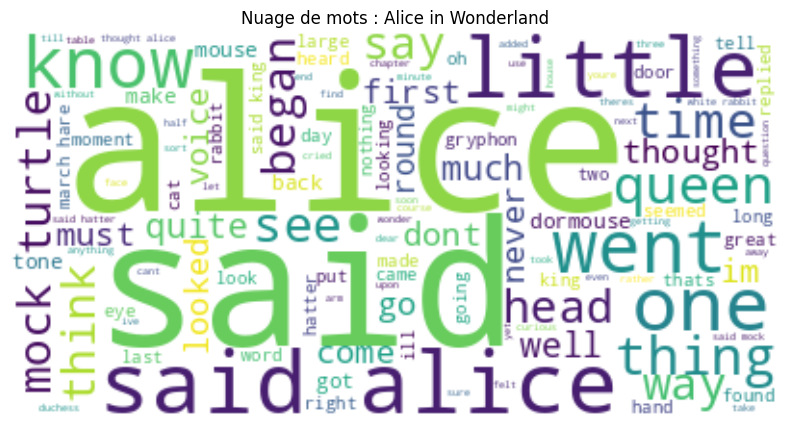

In [25]:
# --- Étape 8 : Identification de la nature des mots (POS Tagging) ---
# On analyse le rôle grammatical (Nom, Adjectif...) des 20 premiers mots
pos_tags = nltk.pos_tag(filtered_corpus[0][:20])
print("Étiquettes POS (20 premiers) :", pos_tags)

# --- Étape 9 : Reconnaissance d'entités (NER) ---
# Identifie les entités nommées comme les personnages ou les lieux
named_entities = nltk.ne_chunk(pos_tags)
print("\nEntités identifiées :", named_entities)

# --- Visualisation : Nuage de mots ---
import matplotlib.pyplot as plt
from wordcloud import WordCloud

def show_wordcloud(text_list, title):
    """Crée une image montrant les mots les plus fréquents en plus gros."""
    # On génère le nuage de mots à partir du texte joint
    wordcloud = WordCloud(background_color='white').generate(" ".join(text_list))
    # Configuration de l'affichage graphique
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title)
    plt.axis("off") # On masque les graduations des axes
    plt.show()

# Génération du nuage de mots pour le premier livre
show_wordcloud(filtered_corpus[0], "Nuage de mots : Alice in Wonderland")


--- Analyse Livre 1 ---
Entités identifiées : [('start', 'NN'), ('project', 'NN'), ('gutenberg', 'NN'), ('ebook', 'NN'), ('illustration', 'NN')]


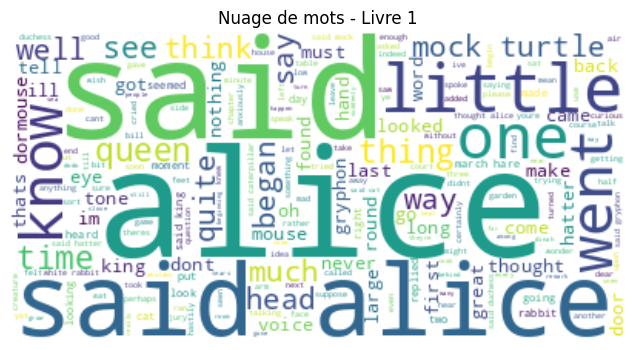


--- Analyse Livre 2 ---
Entités identifiées : [('start', 'NN'), ('project', 'NN'), ('gutenberg', 'NN'), ('ebook', 'NN'), ('illustration', 'NN')]


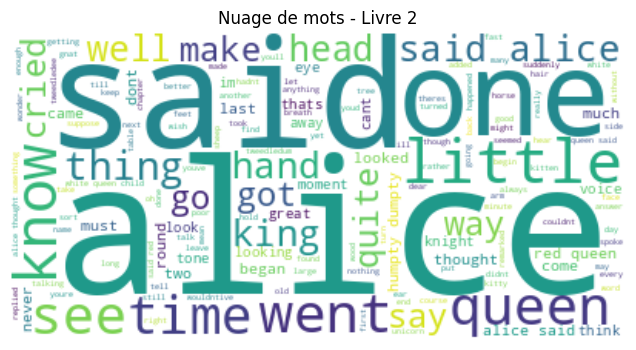


--- Analyse Livre 3 ---
Entités identifiées : [('start', 'NN'), ('project', 'NN'), ('gutenberg', 'NN'), ('ebook', 'NN'), ('taxidermy', 'NN')]


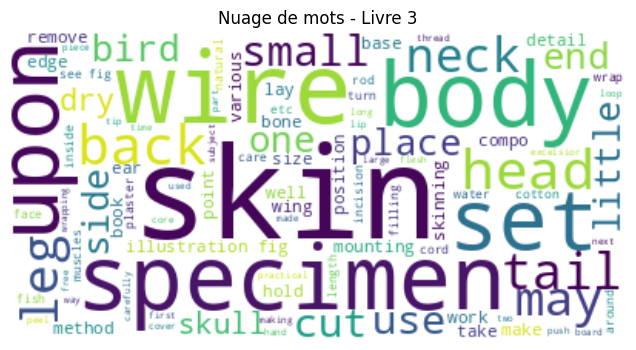

In [14]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

for i, book in enumerate(filtered_corpus):
    print(f"\n--- Analyse Livre {i+1} ---")
    tags = nltk.pos_tag(book[:30])
    entities = nltk.ne_chunk(tags)
    print(f"Entités identifiées : {entities[:5]}")

    wordcloud = WordCloud(background_color='white').generate(" ".join(book))
    plt.figure(figsize=(8, 4))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f"Nuage de mots - Livre {i+1}")
    plt.axis("off")
    plt.show()

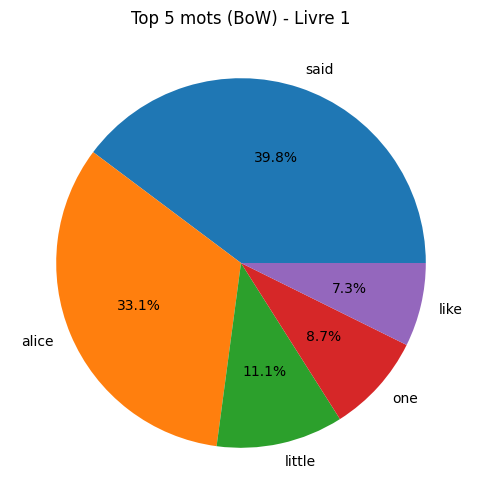

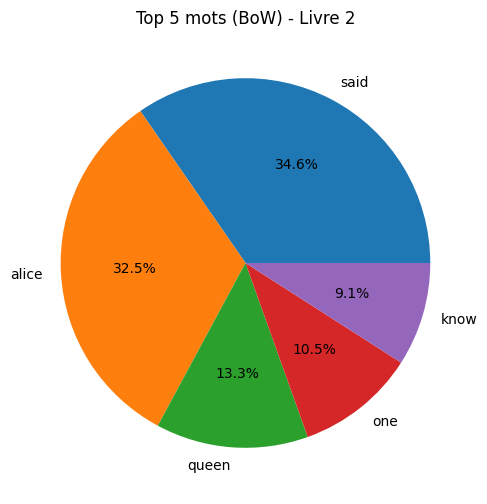

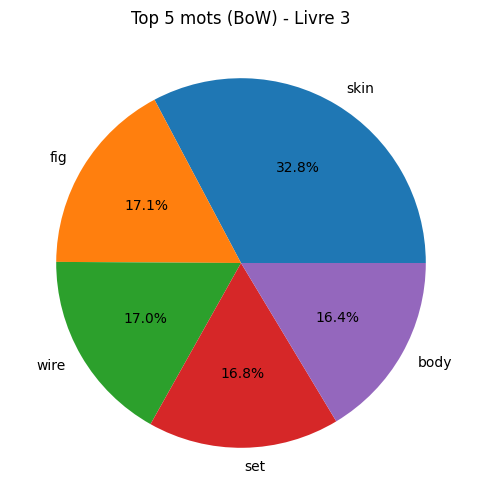


Analyse TF-IDF terminée.


In [22]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import matplotlib.pyplot as plt

# Conversion des listes de mots en chaînes de caractères pour les vectoriseurs
corpus_joined = [" ".join(book) for book in filtered_corpus]

# --- Méthode Bag of Words (BoW) ---
# On compte simplement le nombre d'apparitions de chaque mot
vectorizer = CountVectorizer()
bow_matrix = vectorizer.fit_transform(corpus_joined)
feature_names = vectorizer.get_feature_names_out()

# On parcourt chaque livre pour afficher les 5 mots les plus fréquents
for i, book_text in enumerate(corpus_joined):
    counts = bow_matrix[i].toarray().flatten()
    # On trie pour trouver les 5 plus grands comptes
    top_indices = counts.argsort()[-5:][::-1]
    top_words = [feature_names[idx] for idx in top_indices]
    top_counts = [counts[idx] for idx in top_indices]

    # Affichage du graphique en camembert
    plt.figure(figsize=(6, 6))
    plt.pie(top_counts, labels=top_words, autopct='%1.1f%%')
    plt.title(f"Top 5 mots (BoW) - Livre {i+1}")
    plt.show()

# --- Méthode TF-IDF ---
# Donne du poids aux mots rares et pénalise les mots trop fréquents (ex: 'alice')
tfidf_vec = TfidfVectorizer(min_df=1, max_df=2)
tfidf_matrix = tfidf_vec.fit_transform(corpus_joined)
tfidf_features = tfidf_vec.get_feature_names_out()

print("\nAnalyse TF-IDF terminée.")

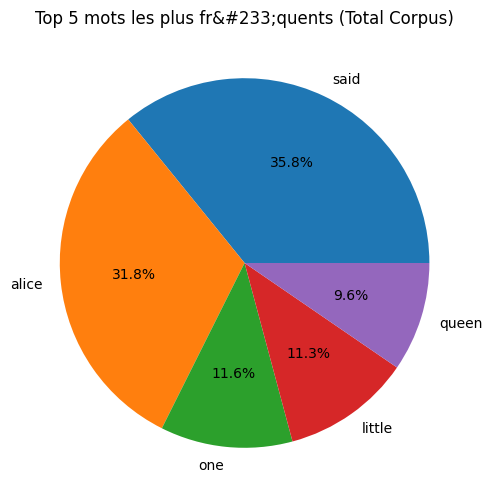

Mots fr&#233;quents : ['said', 'alice', 'one', 'little', 'queen']
Analyse : Ces mots sont informatifs sur les personnages (Alice) mais moins sur les th&#232;mes sp&#233;cifiques, d'o&#249; l'utilit&#233; du TF-IDF.


In [21]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
# Correction BoW : Top 5 sur tout le corpus
corpus_joined = [" ".join(book) for book in filtered_corpus]
all_text = " ".join(corpus_joined)
vectorizer = CountVectorizer()
bow_matrix = vectorizer.fit_transform([all_text])
words = vectorizer.get_feature_names_out()
counts = bow_matrix.toarray().flatten()

top_indices = counts.argsort()[-5:][::-1]
top_words = [words[idx] for idx in top_indices]
top_counts = [counts[idx] for idx in top_indices]

plt.figure(figsize=(6, 6))
plt.pie(top_counts, labels=top_words, autopct='%1.1f%%')
plt.title("Top 5 mots les plus fr&#233;quents (Total Corpus)")
plt.show()

print(f"Mots fr&#233;quents : {top_words}")
print("Analyse : Ces mots sont informatifs sur les personnages (Alice) mais moins sur les th&#232;mes sp&#233;cifiques, d'o&#249; l'utilit&#233; du TF-IDF.")

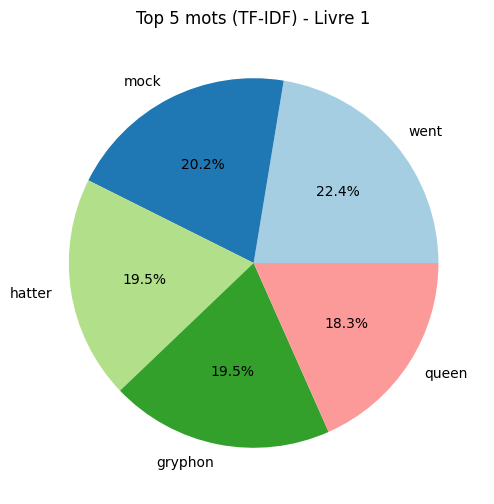

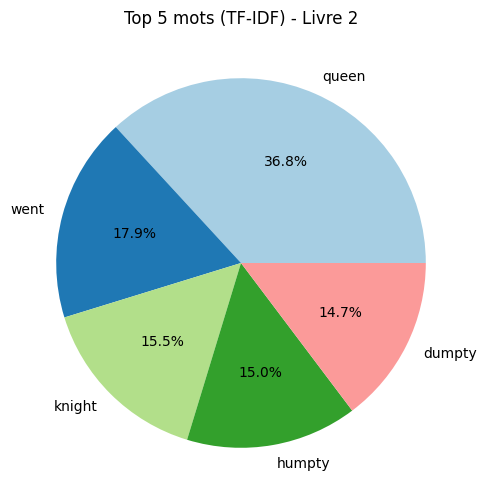

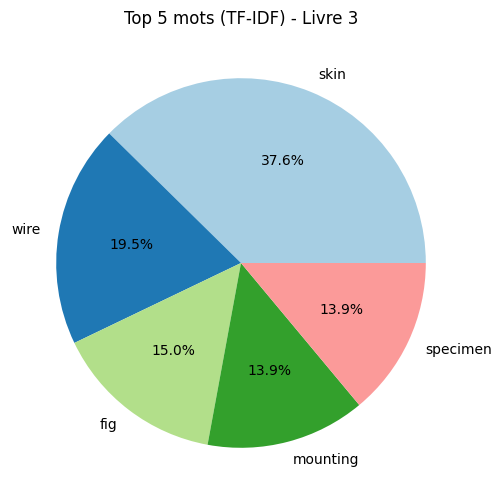

Analyse terminée ! Comparez avec BoW pour voir comment TF-IDF élimine les mots trop communs.


In [17]:
import numpy as np
import matplotlib.pyplot as plt

# --- Visualisation des résultats TF-IDF ---
# Cette boucle identifie les 5 mots les plus 'significatifs' par livre selon le score TF-IDF

for i in range(len(corpus_joined)):
    # Extraction des scores pour le livre i
    tfidf_scores = tfidf_matrix[i].toarray().flatten()
    # Sélection des indices des 5 scores les plus élevés
    top_tfidf_indices = tfidf_scores.argsort()[-5:][::-1]

    # Récupération des mots et de leurs scores correspondants
    top_tfidf_words = [tfidf_features[idx] for idx in top_tfidf_indices]
    top_tfidf_values = [tfidf_scores[idx] for idx in top_tfidf_indices]

    # Affichage sous forme de diagramme circulaire
    plt.figure(figsize=(6, 6))
    # Utilisation d'une palette de couleurs variées
    plt.pie(top_tfidf_values, labels=top_tfidf_words, autopct='%1.1f%%', colors=plt.cm.Paired.colors)
    plt.title(f"Top 5 mots (TF-IDF) - Livre {i+1}")
    plt.show()

print("Analyse terminée ! Comparez avec BoW pour voir comment TF-IDF élimine les mots trop communs.")

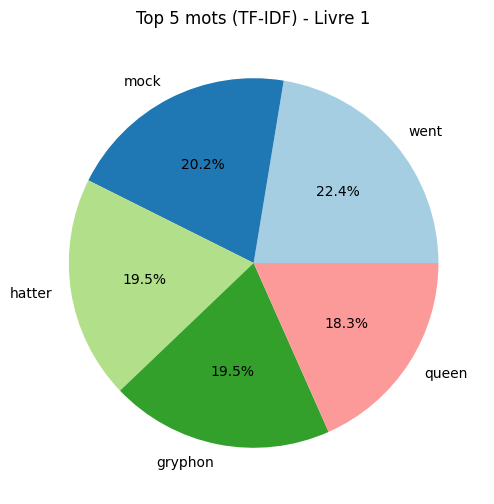

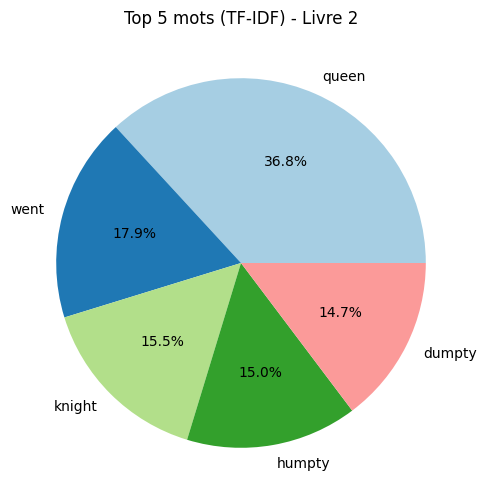

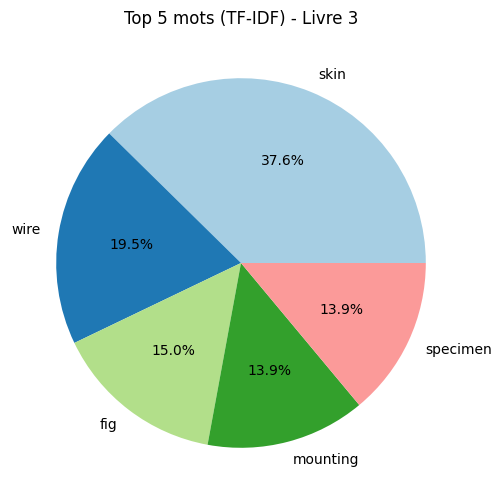

Analyse terminée ! Vous pouvez maintenant comparer les graphiques BoW et TF-IDF.


In [11]:
import numpy as np

# --- Visualisation TF-IDF (Étape Finale) ---
# Nous récupérons les 5 mots avec le score TF-IDF le plus élevé pour chaque livre

for i in range(len(corpus_joined)):
    tfidf_scores = tfidf_matrix[i].toarray().flatten()
    # On récupère les indices des 5 meilleurs scores
    top_tfidf_indices = tfidf_scores.argsort()[-5:][::-1]

    top_tfidf_words = [tfidf_features[idx] for idx in top_tfidf_indices]
    top_tfidf_values = [tfidf_scores[idx] for idx in top_tfidf_indices]

    # Création du graphique
    plt.figure(figsize=(6, 6))
    plt.pie(top_tfidf_values, labels=top_tfidf_words, autopct='%1.1f%%', colors=plt.cm.Paired.colors)
    plt.title(f"Top 5 mots (TF-IDF) - Livre {i+1}")
    plt.show()

print("Analyse terminée ! Vous pouvez maintenant comparer les graphiques BoW et TF-IDF.")

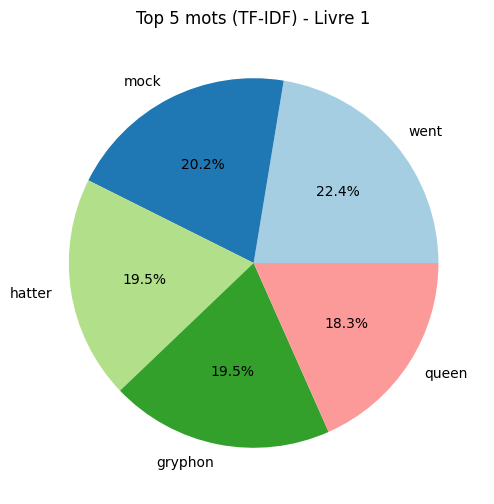

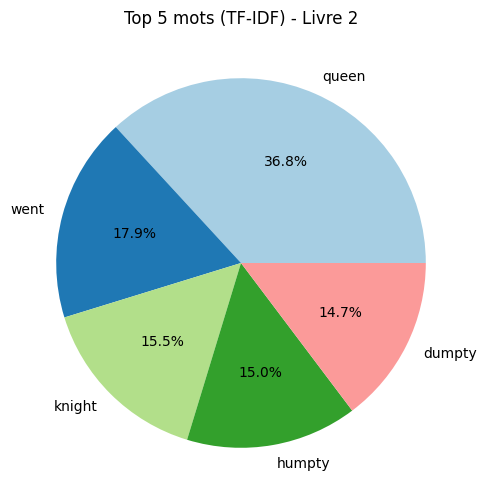

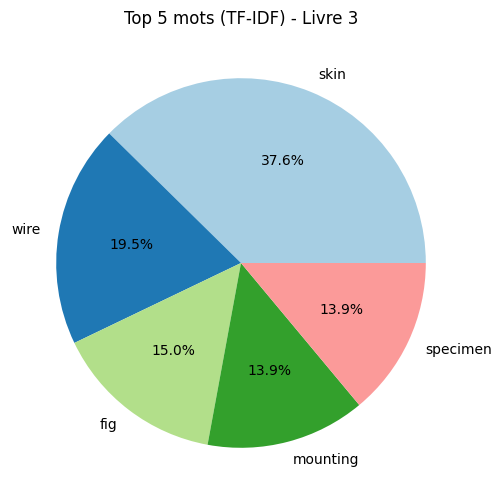

Analyse terminée ! Vous pouvez maintenant comparer les graphiques BoW et TF-IDF.


In [10]:
import numpy as np

# --- Visualisation TF-IDF (Étape Finale) ---
# Nous récupérons les 5 mots avec le score TF-IDF le plus élevé pour chaque livre

for i in range(len(corpus_joined)):
    tfidf_scores = tfidf_matrix[i].toarray().flatten()
    # On récupère les indices des 5 meilleurs scores
    top_tfidf_indices = tfidf_scores.argsort()[-5:][::-1]

    top_tfidf_words = [tfidf_features[idx] for idx in top_tfidf_indices]
    top_tfidf_values = [tfidf_scores[idx] for idx in top_tfidf_indices]

    # Création du graphique
    plt.figure(figsize=(6, 6))
    plt.pie(top_tfidf_values, labels=top_tfidf_words, autopct='%1.1f%%', colors=plt.cm.Paired.colors)
    plt.title(f"Top 5 mots (TF-IDF) - Livre {i+1}")
    plt.show()

print("Analyse terminée ! Vous pouvez maintenant comparer les graphiques BoW et TF-IDF.")